# Segmentación de Objetos con K-Means

## Parte 1: `datosObjetos.csv`

In [25]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.cluster import adjusted_rand_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [26]:
datos = pd.read_csv("datosObjetos.csv")
X = datos[['t (s)', 'y (m)', 'Área (m^2)']]
k = 10

### 1. Clasificación básica

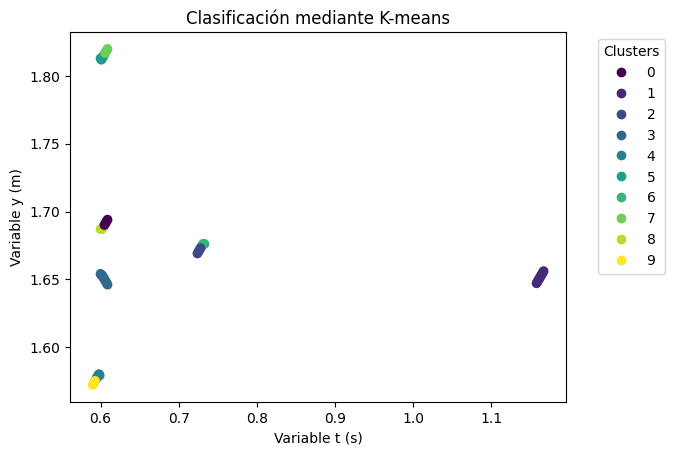

In [27]:
kmeans = KMeans(n_clusters=k, n_init='auto')
kmeans.fit(X)

scatter = plt.scatter(X['t (s)'], X['y (m)'], c=kmeans.labels_, cmap='viridis')
plt.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Clasificación mediante K-means")
plt.xlabel("Variable t (s)")
plt.ylabel("Variable y (m)")
plt.show()

### 2. División en entrenamiento y prueba con métricas

Puntuación de silueta: 0.5688302676584683
Puntuación ajustada de Rand: 1.0


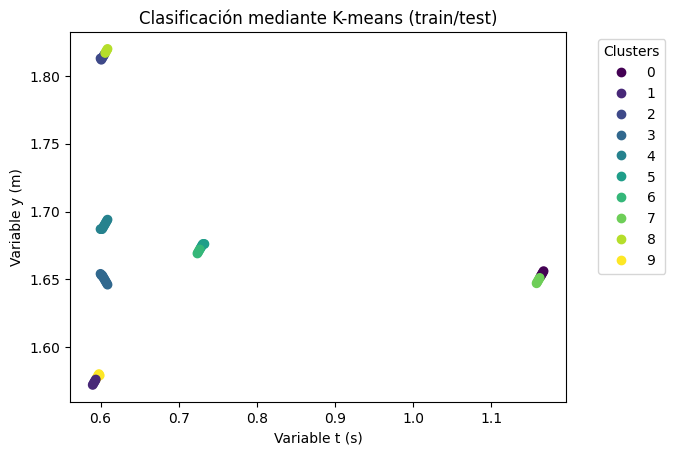

In [28]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
kmeans = KMeans(n_clusters=k, n_init='auto')
kmeans.fit(X_train)

etiquetas_test = kmeans.predict(X_test)
etiquetas_train = kmeans.predict(X_train)

silhouette_avg = silhouette_score(X_test, etiquetas_test)
adjusted_rand_index = adjusted_rand_score(etiquetas_train, kmeans.labels_)
print(f"Puntuación de silueta: {silhouette_avg}")
print(f"Puntuación ajustada de Rand: {adjusted_rand_index}")

X_test = X_test.copy()
X_train = X_train.copy()
X_test['cluster'] = etiquetas_test
X_train['cluster'] = etiquetas_train
datos['cluster'] = pd.concat([X_train['cluster'], X_test['cluster']])

scatter = plt.scatter(datos['t (s)'], datos['y (m)'], c=datos['cluster'], cmap='viridis')
plt.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Clasificación mediante K-means (train/test)")
plt.xlabel("Variable t (s)")
plt.ylabel("Variable y (m)")
plt.show()

### 3. Métricas vs porcentaje de entrenamiento

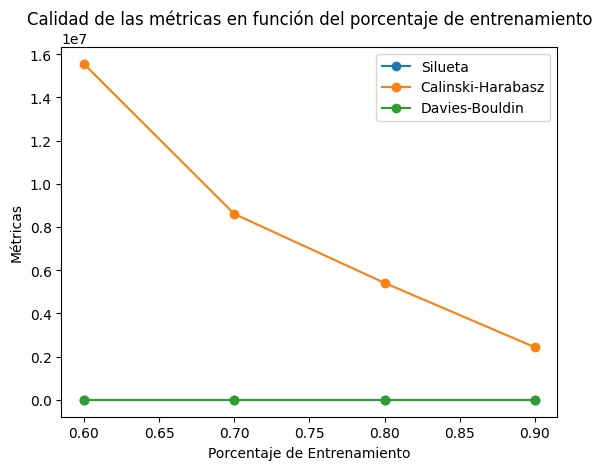

In [29]:
porcentajes_entrenamiento = [0.6, 0.7, 0.8, 0.9]
silueta_scores, calinski_harabasz_scores, davies_bouldin_scores = [], [], []

for p in porcentajes_entrenamiento:
    X_train, X_test = train_test_split(X, test_size=1-p, random_state=42)
    kmeans = KMeans(n_clusters=k, n_init='auto')
    kmeans.fit(X_train)
    etiquetas_test = kmeans.predict(X_test)

    silueta_scores.append(silhouette_score(X_test, etiquetas_test))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_test, etiquetas_test))
    davies_bouldin_scores.append(davies_bouldin_score(X_test, etiquetas_test))

plt.plot(porcentajes_entrenamiento, silueta_scores, marker='o', label='Silueta')
plt.plot(porcentajes_entrenamiento, calinski_harabasz_scores, marker='o', label='Calinski-Harabasz')
plt.plot(porcentajes_entrenamiento, davies_bouldin_scores, marker='o', label='Davies-Bouldin')
plt.title("Calidad de las métricas en función del porcentaje de entrenamiento")
plt.xlabel("Porcentaje de Entrenamiento")
plt.ylabel("Métricas")
plt.legend()
plt.show()

### 4. Fronteras de decisión

> **Nota:** El código original usaba `alpha=0`, lo que hacía las fronteras invisibles. Corregido a `alpha=0.3`.

/home/byob/Documents/Computational/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


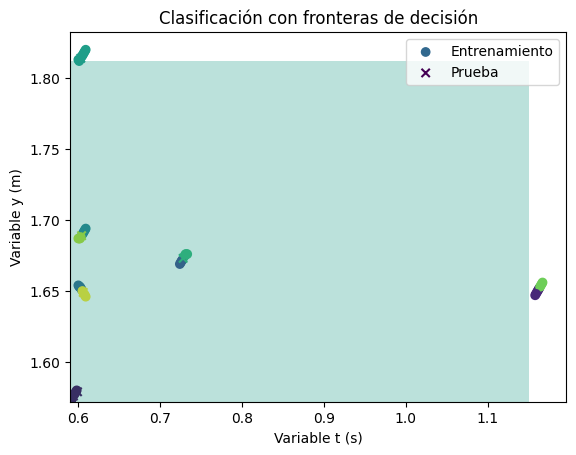

In [30]:
X_train, X_test = train_test_split(X, test_size=0.1, random_state=42)
kmeans = KMeans(n_clusters=k, n_init='auto')
kmeans.fit(X_train)
etiquetas_test = kmeans.predict(X_test)

plt.scatter(X_train['t (s)'], X_train['y (m)'], c=kmeans.labels_, label='Entrenamiento')
plt.scatter(X_test['t (s)'], X_test['y (m)'], c=etiquetas_test, marker='x', label='Prueba')

h = 0.02
xx, yy = np.meshgrid(np.arange(X['t (s)'].min(), X['t (s)'].max(), h),
                     np.arange(X['y (m)'].min(), X['y (m)'].max(), h))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel())])
plt.contourf(xx, yy, Z.reshape(xx.shape), levels=k, cmap='viridis', alpha=0.3)

plt.legend()
plt.title("Clasificación con fronteras de decisión")
plt.xlabel("Variable t (s)")
plt.ylabel("Variable y (m)")
plt.show()

### 5. Centroides

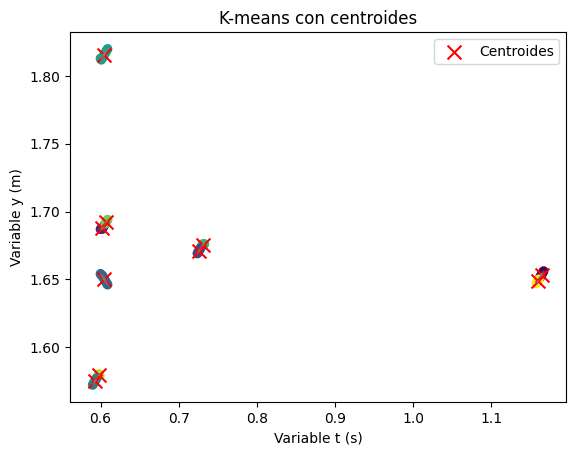

In [31]:
kmeans = KMeans(n_clusters=k, n_init='auto')
kmeans.fit(X)
centroides = kmeans.cluster_centers_

plt.scatter(X['t (s)'], X['y (m)'], c=kmeans.labels_)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='x', s=100, label='Centroides')

for i in range(len(X)):
    plt.plot([X.iloc[i]['t (s)'], centroides[kmeans.labels_[i]][0]],
             [X.iloc[i]['y (m)'], centroides[kmeans.labels_[i]][1]], c='gray', alpha=0.3)

plt.legend()
plt.title("K-means con centroides")
plt.xlabel("Variable t (s)")
plt.ylabel("Variable y (m)")
plt.show()

## Parte 2: `datosObjetos_.csv`

In [32]:
from sklearn.metrics import mutual_info_score, adjusted_mutual_info_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [33]:
datos = pd.read_csv("datosObjetos.csv")
datos

,t (s),y (m),Área (m^2),Objeto
0,0.599,1.579,55.90,Tarjeta
1,0.598,1.580,55.91,Tarjeta
2,0.597,1.579,55.92,Tarjeta
3,0.596,1.578,55.93,Tarjeta
4,0.595,1.577,55.94,Tarjeta
5,0.594,1.576,55.95,Tarjeta
6,0.593,1.575,55.96,Tarjeta
7,0.592,1.574,55.97,Tarjeta
8,0.591,1.573,55.98,Tarjeta
9,0.590,1.572,55.99,Tarjeta


In [34]:
scaler = StandardScaler()
columnas_numericas = datos.select_dtypes(include=['float64', 'int64']).columns
datos[columnas_numericas] = scaler.fit_transform(datos[columnas_numericas])
print(datos)

       t (s)     y (m)  Área (m^2)       Objeto
0  -0.573768 -1.352293   -0.734313      Tarjeta
1  -0.578651 -1.338371   -0.734211      Tarjeta
2  -0.583534 -1.352293   -0.734108      Tarjeta
3  -0.588417 -1.366215   -0.734005      Tarjeta
4  -0.593300 -1.380137   -0.733902      Tarjeta
5  -0.598183 -1.394059   -0.733799      Tarjeta
6  -0.603067 -1.407981   -0.733696      Tarjeta
7  -0.607950 -1.421903   -0.733594      Tarjeta
8  -0.612833 -1.435825   -0.733491      Tarjeta
9  -0.617716 -1.449747   -0.733388      Tarjeta
10 -0.568885  1.905462    0.055697  Chocolatina
11 -0.564002  1.891540    0.055800  Chocolatina
12 -0.559118  1.905462    0.055903  Chocolatina
13 -0.554235  1.919384    0.056006  Chocolatina
14 -0.549352  1.933306    0.056109  Chocolatina
15 -0.544469  1.947228    0.056211  Chocolatina
16 -0.539586  1.961150    0.056314  Chocolatina
17 -0.534703  1.975072    0.056417  Chocolatina
18 -0.529820  1.988994    0.056520  Chocolatina
19 -0.524936  2.002916    0.056623  Choc

In [35]:
X = datos.iloc[:,:-1]
y = datos['Objeto']

### 1. Escalado MinMax

In [36]:
scale = MinMaxScaler()
X = scale.fit_transform(X)
pd.DataFrame(X).describe()

,0,1,2
count,60.000000,60.000000,60.000000
mean,0.219237,0.419892,0.360057
std,0.357911,0.292076,0.323032
min,0.000000,0.000000,0.000000
25%,0.019064,0.309476,0.124992
50%,0.027730,0.364919,0.304315
75%,0.239601,0.472782,0.426721
max,1.000000,1.000000,1.000000


### 2. Reducción dimensional con PCA

In [37]:
pca = PCA(n_components=2).fit(X)
X_pca = pca.transform(X)

### 3. Método del codo

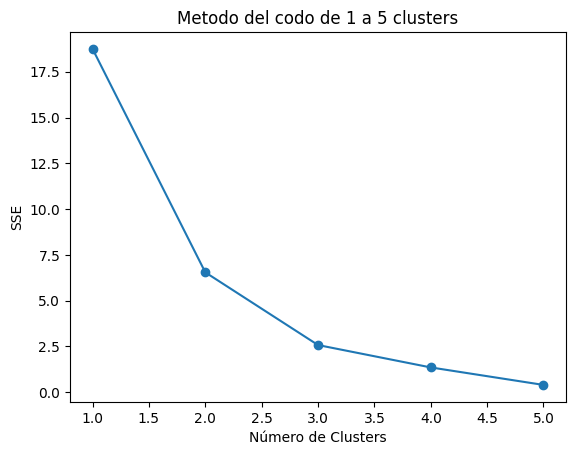

In [38]:
SSE = []
numClusters = list(range(1, 6))
for n in numClusters:
    k_means = KMeans(n_clusters=n, n_init='auto')
    k_means.fit(X)
    SSE.append(k_means.inertia_)

plt.plot(numClusters, SSE, marker="o")
plt.title("Metodo del codo de 1 a 5 clusters")
plt.xlabel('Número de Clusters')
plt.ylabel('SSE')
plt.show()

### 4. Clustering final (k=3)

In [39]:
kmeans = KMeans(n_clusters=3, n_init=20, max_iter=50, random_state=1).fit(X)
kmeans_labels = kmeans.predict(X) #`fit_predict` entrena el modelo y devuelve las predicciones

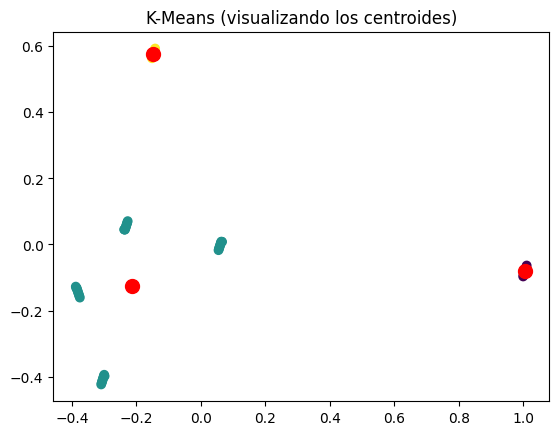

In [40]:
# centroides resultantes del clustering
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=100, facecolors='r')
plt.title("K-Means (visualizando los centroides)")
plt.show();